# U.S. Retail Sales — Time Series Analysis
### PostgreSQL · Python · Pandas

---

**Author:** Teslim Adeyanju, ACA  
**Dataset:** U.S. Census Bureau — Monthly Retail Trade Survey (`us_retail_sales-2.csv`)  
**Period:** January 1992 – December 2020  
**Tools:** Python 3, Pandas, PostgreSQL 15/16, SQLAlchemy, Matplotlib, Seaborn

---

## Project Overview

This notebook walks through the **end-to-end workflow** for a time-series retail sales analysis:

| Phase | Description |
|-------|-------------|
| **1. Data Loading & Exploration** | Ingest the raw CSV and profile the dataset |
| **2. Data Cleaning** | Fix dtypes, parse dates, handle nulls |
| **3. Database Pipeline** | Upload cleaned data to PostgreSQL |
| **4. Date/Time Fundamentals** | PostgreSQL date functions as a reference guide |
| **5. Retail Sales Analysis** | Aggregations, window functions, index & trend analysis |
| **6. Visualisations** | Charts for key insights |

> **Note:** Database credentials are loaded from environment variables. Copy `.env.example` → `.env` and fill in your values before running.

---
## Setup & Imports

In [1]:
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 10)

# Plot style
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [48]:
import subprocess
import sys

# Install required packages (install only if not already present)
packages = {'psycopg2-binary': 'psycopg2', 'sqlalchemy': 'sqlalchemy', 'python-dotenv': 'dotenv'}

for pkg, import_name in packages.items():
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

# Import modules
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import psycopg2

print('All database packages ready.')

All database packages ready.


---
## 1. Data Loading & Initial Exploration

The dataset contains monthly retail sales figures from the U.S. Census Bureau, broken down by **kind of business** (65 categories) and tagged with NAICS codes.

In [3]:
df_raw = pd.read_csv('us_retail_sales-2.csv')

print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'\nColumn names: {df_raw.columns.tolist()}')
df_raw.head(10)

Shape: 22,620 rows × 5 columns

Column names: ['sales_month', 'naics_code', 'kind_of_business', 'reason_for_null', 'sales']


,sales_month,naics_code,kind_of_business,reason_for_null,sales
0,1/1/92,441,Motor vehicle and parts dealers,NaN,"29,811.00"
1,1/1/92,4411,Automobile dealers,NaN,"25,800.00"
2,1/1/92,"4411, 4412",Automobile and other motor vehicle dealers,NaN,"26,788.00"
3,1/1/92,44111,New car dealers,NaN,"24,056.00"
4,1/1/92,44112,Used car dealers,NaN,"1,744.00"
5,1/1/92,4413,"Automotive parts, acc., and tire stores",NaN,"3,023.00"
6,1/1/92,442,Furniture and home furnishings stores,NaN,"3,846.00"
7,1/1/92,"442, 443","Furniture, home furn, electronics, and applian...",NaN,"7,503.00"
8,1/1/92,4421,Furniture stores,NaN,"2,392.00"
9,1/1/92,4422,Home furnishings stores,NaN,"1,454.00"


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22620 entries, 0 to 22619
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sales_month       22620 non-null  object 
 1   naics_code        20184 non-null  object 
 2   kind_of_business  22620 non-null  object 
 3   reason_for_null   594 non-null    object 
 4   sales             22026 non-null  float64
dtypes: float64(1), object(4)
memory usage: 883.7+ KB


In [6]:
# Null value audit
null_summary = pd.DataFrame({
    'null_count': df_raw.isnull().sum(),
    'null_pct':   (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print('=== Null Value Summary ===')
null_summary

=== Null Value Summary ===


,null_count,null_pct
sales_month,0,0.00
naics_code,2436,10.77
kind_of_business,0,0.00
reason_for_null,22026,97.37
sales,594,2.63


In [7]:
# Unique business categories
categories = df_raw['kind_of_business'].unique()
print(f'Unique business categories: {len(categories)}')
print('\nSample categories:')
for c in sorted(categories)[:15]:
    print(f'  - {c}')

Unique business categories: 65

Sample categories:
  - All other gen. merchandise stores
  - All other home furnishings stores
  - Automobile and other motor vehicle dealers
  - Automobile dealers
  - Automotive parts, acc., and tire stores
  - Beer, wine, and liquor stores
  - Book stores
  - Building mat. and garden equip. and supplies dealers
  - Building mat. and supplies dealers
  - Clothing and clothing access. stores
  - Clothing stores
  - Department stores
  - Department stores(excl. discount department stores)
  - Discount dept. stores
  - Drinking places


In [8]:
# Date range (raw, before parsing)
print(f"Date range (raw): {df_raw['sales_month'].min()}  →  {df_raw['sales_month'].max()}")
print(f"Sales stats:\n{df_raw['sales'].describe()}")

Date range (raw): 1/1/00  →  9/1/99
Sales stats:
count    22,026.00
mean     42,050.89
std      85,895.73
min          12.00
25%       2,530.00
50%       8,950.50
75%      34,947.00
max     611,429.00
Name: sales, dtype: float64


---
## 2. Data Cleaning

Steps:
1. Parse `sales_month` as proper `datetime64`
2. Cast `naics_code` to `string` (it contains mixed codes like `'4411, 4412'`)
3. Cast `kind_of_business` and `reason_for_null` to `string`
4. Verify no structural issues remain

In [9]:
df = df_raw.copy()

# 1. Parse dates — explicit format avoids dateutil fallback warnings
df['sales_month'] = pd.to_datetime(df['sales_month'], format='%m/%d/%y')

# 2. String columns
df['naics_code']        = df['naics_code'].astype('string')
df['kind_of_business']  = df['kind_of_business'].astype('string')
df['reason_for_null']   = df['reason_for_null'].astype('string')

# 3. Ensure sales is float
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

print('=== After Cleaning ===')
df.info()

=== After Cleaning ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22620 entries, 0 to 22619
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sales_month       22620 non-null  datetime64[ns]
 1   naics_code        20184 non-null  string        
 2   kind_of_business  22620 non-null  string        
 3   reason_for_null   594 non-null    string        
 4   sales             22026 non-null  float64       
dtypes: datetime64[ns](1), float64(1), string(3)
memory usage: 883.7 KB


In [10]:
# Verify date range post-parse
print(f"Date range: {df['sales_month'].min().date()}  →  {df['sales_month'].max().date()}")
print(f"Distinct months: {df['sales_month'].nunique()}")
print(f"Distinct business types: {df['kind_of_business'].nunique()}")

# Confirm no duplicates
dupes = df.duplicated(subset=['sales_month','kind_of_business']).sum()
print(f"Duplicate (month + business) pairs: {dupes}")

Date range: 1992-01-01  →  2020-12-01
Distinct months: 348
Distinct business types: 65
Duplicate (month + business) pairs: 0


In [11]:
df.head()

,sales_month,naics_code,kind_of_business,reason_for_null,sales
0,1992-01-01,441,Motor vehicle and parts dealers,<NA>,"29,811.00"
1,1992-01-01,4411,Automobile dealers,<NA>,"25,800.00"
2,1992-01-01,"4411, 4412",Automobile and other motor vehicle dealers,<NA>,"26,788.00"
3,1992-01-01,44111,New car dealers,<NA>,"24,056.00"
4,1992-01-01,44112,Used car dealers,<NA>,"1,744.00"


---
## 3. Database Pipeline — Upload to PostgreSQL

Credentials are read from environment variables (or a `.env` file) — **never hard-coded**.

```
# .env
PG_HOST=localhost
PG_PORT=5432
PG_DB=us_retail_report_db
PG_USER=postgres
PG_PASS=your_password_here
```

In [20]:
# Load credentials from .env
load_dotenv()

PG_HOST = os.getenv('PG_HOST', 'localhost')
PG_PORT = os.getenv('PG_PORT', '5432')
PG_DB   = os.getenv('PG_DB',   'us_retail_report_db')
PG_USER = os.getenv('PG_USER', 'postgres')
PG_PASS = os.getenv('PG_PASS', '')

CONNECTION_STRING = f'postgresql://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}'

# Test connection
try:
    engine = create_engine(CONNECTION_STRING)
    with engine.connect() as conn:
        conn.execute(text('SELECT 1'))
    print(f'✓ Connected to PostgreSQL → {PG_DB} on {PG_HOST}:{PG_PORT}')
except Exception as e:
    print(f'✗ Connection failed: {e}')

✓ Connected to PostgreSQL → us_retail_report_db on localhost:5432


In [21]:
# Upload cleaned data — replace table on each run to avoid duplicates
try:
    df.to_sql(
        name='retail_sales',
        con=engine,
        if_exists='replace',   # DROP + recreate — ensures clean slate
        index=False,
        method='multi'
    )
    print(f'Uploaded {len(df):,} rows to retail_sales table.')
except Exception as e:
    print(f'Upload failed: {e}')

Uploaded 22,620 rows to retail_sales table.


In [22]:
# Verify upload
verify_q = """
SELECT
    COUNT(*)                    AS total_rows,
    COUNT(DISTINCT sales_month) AS distinct_months,
    COUNT(DISTINCT kind_of_business) AS distinct_businesses,
    MIN(sales_month)            AS earliest_month,
    MAX(sales_month)            AS latest_month
FROM retail_sales;
"""
pd.read_sql_query(verify_q, engine)

,total_rows,distinct_months,distinct_businesses,earliest_month,latest_month
0,22620,348,65,1992-01-01,2020-12-01


In [23]:
# PostgreSQL table schema
schema_q = """
SELECT column_name, data_type, is_nullable
FROM information_schema.columns
WHERE table_name = 'retail_sales'
ORDER BY ordinal_position;
"""
pd.read_sql_query(schema_q, engine)

,column_name,data_type,is_nullable
0,sales_month,timestamp without time zone,YES
1,naics_code,text,YES
2,kind_of_business,text,YES
3,reason_for_null,text,YES
4,sales,double precision,YES


In [24]:
# Helper: run a SQL query → DataFrame
def sql(query: str) -> pd.DataFrame:
    """Execute a SELECT query and return results as a DataFrame."""
    return pd.read_sql_query(query, engine)

print('sql() helper ready.')

sql() helper ready.


---
## 4. PostgreSQL Date/Time Fundamentals

A practical reference covering the core date/time functions used in time-series analysis.  
All examples run against a live PostgreSQL connection.

### 4.1 Current Date & Time Functions

| Function | Returns | Notes |
|----------|---------|-------|
| `CURRENT_DATE` | `DATE` | Date only, no time |
| `LOCALTIMESTAMP` | `TIMESTAMP` | No time zone |
| `CURRENT_TIMESTAMP` / `NOW()` | `TIMESTAMPTZ` | With time zone |
| `CURRENT_TIME` | `TIMETZ` | Current time |
| `LOCALTIME` | `TIME` | Local time, no zone |

In [25]:
sql("""
SELECT
    CURRENT_DATE                   AS current_date,
    LOCALTIMESTAMP                 AS local_timestamp,
    CURRENT_TIMESTAMP              AS current_timestamptz,
    NOW()                          AS now_timestamptz,
    CURRENT_TIME                   AS current_time,
    LOCALTIME                      AS local_time;
""")

,current_date,local_timestamp,current_timestamptz,now_timestamptz,current_time,local_time
0,2026-03-10,2026-03-10 00:42:44.491473,2026-03-10 00:42:44.491473+00:00,2026-03-10 00:42:44.491473+00:00,00:42:44.491473+00:00,00:42:44.491473


### 4.2 Truncating Timestamps — `DATE_TRUNC`

`DATE_TRUNC(precision, timestamp)` rounds a timestamp *down* to the start of the chosen precision unit.  
**Key detail:** week truncation uses **Monday** as the first day of the week in PostgreSQL.

In [26]:
sql("""
SELECT
    DATE_TRUNC('year', TIMESTAMP '2025-08-22 22:19:58') AS trunc_year,
    DATE_TRUNC('month',TIMESTAMP '2025-08-22 22:19:58') AS trunc_month,
    DATE_TRUNC('week', TIMESTAMP '2025-08-22 22:19:58') AS trunc_week,
    DATE_TRUNC('day',  TIMESTAMP '2025-08-22 22:19:58') AS trunc_day,
    DATE_TRUNC('hour', TIMESTAMP '2025-08-22 22:19:58') AS trunc_hour;
""")

,trunc_year,trunc_month,trunc_week,trunc_day,trunc_hour
0,2025-01-01,2025-08-01,2025-08-18,2025-08-22,2025-08-22 22:00:00


### 4.3 Extracting Date Parts — `DATE_PART` / `EXTRACT`

Both functions return a `DOUBLE PRECISION` number. `EXTRACT` is the ANSI-standard syntax.

In [27]:
sql("""
SELECT
    -- date_part (Postgres-specific)
    DATE_PART('day',   CURRENT_TIMESTAMP) AS day_of_month,
    DATE_PART('month', CURRENT_TIMESTAMP) AS month_of_year,
    DATE_PART('year',  CURRENT_TIMESTAMP) AS year_number,
    DATE_PART('week',  CURRENT_TIMESTAMP) AS iso_week,
    DATE_PART('dow',   CURRENT_TIMESTAMP) AS day_of_week_0sun,
    DATE_PART('quarter', CURRENT_TIMESTAMP) AS quarter,
    -- EXTRACT (ANSI-standard equivalent)
    EXTRACT(HOUR FROM CURRENT_TIMESTAMP)  AS hour_of_day;
""")

,day_of_month,month_of_year,year_number,iso_week,day_of_week_0sun,quarter,hour_of_day
0,10.00,3.00,"2,026.00",11.00,2.00,1.00,0.00


### 4.4 Human-Readable Formatting — `TO_CHAR`

`TO_CHAR(value, format)` converts dates/numbers to formatted strings.  
See: [PostgreSQL formatting docs](https://www.postgresql.org/docs/current/functions-formatting.html)

In [28]:
sql("""
SELECT
    TO_CHAR(CURRENT_TIMESTAMP, 'Day')          AS day_name_full,
    TO_CHAR(CURRENT_TIMESTAMP, 'Dy')           AS day_name_abbr,
    TO_CHAR(CURRENT_TIMESTAMP, 'Month')        AS month_name_full,
    TO_CHAR(CURRENT_TIMESTAMP, 'Mon')          AS month_name_abbr,
    TO_CHAR(CURRENT_TIMESTAMP, 'YYYY-MM-DD')   AS iso_date,
    TO_CHAR(CURRENT_TIMESTAMP, 'DD/MM/YYYY')   AS uk_date,
    TO_CHAR(CURRENT_TIMESTAMP, 'Month DD, YYYY') AS long_date;
""")

,day_name_full,day_name_abbr,month_name_full,month_name_abbr,iso_date,uk_date,long_date
0,Tuesday,Tue,March,Mar,2026-03-10,10/03/2026,"March 10, 2026"


### 4.5 Constructing & Parsing Dates — `MAKE_DATE` / `TO_DATE`

In [29]:
sql("""
SELECT
    -- Build a date from integer parts
    MAKE_DATE(1977, 10, 26)                                     AS birthday,

    -- Parse a string into DATE using an explicit format mask
    TO_DATE(CONCAT('2020','-','09','-','01'), 'YYYY-MM-DD')     AS parsed_date,
    TO_DATE('26 Oct 1977', 'DD Mon YYYY')                       AS alt_parsed;
""")

,birthday,parsed_date,alt_parsed
0,1977-10-26,2020-09-01,1977-10-26


### 4.6 Date Arithmetic

| Operation | Result type | Notes |
|-----------|-------------|-------|
| `date - date` | `INTEGER` | Days between |
| `AGE(later, earlier)` | `INTERVAL` | Years-months-days |
| `date + INTERVAL` | `TIMESTAMP` | Add a duration |

In [30]:
sql("""
SELECT
    -- Days between two dates (integer result)
    DATE '2025-08-26' - DATE '1977-10-26'              AS days_alive,

    -- AGE returns a human-readable interval
    AGE(DATE '2025-10-25', DATE '1977-10-26')          AS age_interval,

    -- Extract specific parts from the AGE interval
    EXTRACT(YEAR  FROM AGE(DATE '2025-10-25', DATE '1977-10-26')) AS years_part,
    EXTRACT(MONTH FROM AGE(DATE '2025-10-25', DATE '1977-10-26')) AS months_part,
    EXTRACT(DAY   FROM AGE(DATE '2025-10-25', DATE '1977-10-26')) AS days_part,

    -- Add an INTERVAL to a date
    DATE '1977-10-26' + INTERVAL '48 years'            AS birthday_plus_48;
""")

,days_alive,age_interval,years_part,months_part,days_part,birthday_plus_48
0,17471,17515 days,47.00,11.00,30.00,2025-10-26


### 4.7 Time Arithmetic

You can add/subtract `INTERVAL`s to/from `TIME` values. Note: multiplying a `TIME` by a number is **not valid** — multiply the `INTERVAL` instead.

In [31]:
sql("""
SELECT
    TIME '05:00' + INTERVAL '3 hours'        AS time_plus_3h,
    TIME '05:00' - INTERVAL '3 hours'        AS time_minus_3h,
    INTERVAL '1 second' * 2000               AS interval_2000s,   -- 33 min 20 sec
    TIME '05:00' + (INTERVAL '1 hour' * 2)   AS time_plus_2h;
""")

,time_plus_3h,time_minus_3h,interval_2000s,time_plus_2h
0,08:00:00,02:00:00,0 days 00:33:20,07:00:00


---
## 5. Retail Sales Analysis

All queries run against the `retail_sales` table in PostgreSQL.  
**Table schema:** `sales_month DATE · naics_code TEXT · kind_of_business TEXT · reason_for_null TEXT · sales NUMERIC`

### 5.1 Sample Data Peek

In [32]:
sql("""
SELECT *
FROM retail_sales
ORDER BY sales_month, kind_of_business
LIMIT 10;
""")

,sales_month,naics_code,kind_of_business,reason_for_null,sales
0,1992-01-01,45299,All other gen. merchandise stores,None,"2,111.00"
1,1992-01-01,442299,All other home furnishings stores,Not Available,NaN
2,1992-01-01,"4411, 4412",Automobile and other motor vehicle dealers,None,"26,788.00"
3,1992-01-01,4411,Automobile dealers,None,"25,800.00"
4,1992-01-01,4413,"Automotive parts, acc., and tire stores",None,"3,023.00"
5,1992-01-01,4453,"Beer, wine, and liquor stores",None,"1,509.00"
6,1992-01-01,451211,Book stores,None,790.00
7,1992-01-01,444,Building mat. and garden equip. and supplies d...,None,"8,964.00"
8,1992-01-01,4441,Building mat. and supplies dealers,None,"7,637.00"
9,1992-01-01,448,Clothing and clothing access. stores,None,"6,938.00"


### 5.2 Monthly Trend — Total Retail & Food Services

In [33]:
monthly_total = sql("""
SELECT
    sales_month,
    sales
FROM retail_sales
WHERE kind_of_business = 'Retail and food services sales, total'
ORDER BY sales_month;
""")
monthly_total.head()

,sales_month,sales
0,1992-01-01,"146,376.00"
1,1992-02-01,"147,079.00"
2,1992-03-01,"159,336.00"
3,1992-04-01,"163,669.00"
4,1992-05-01,"170,068.00"


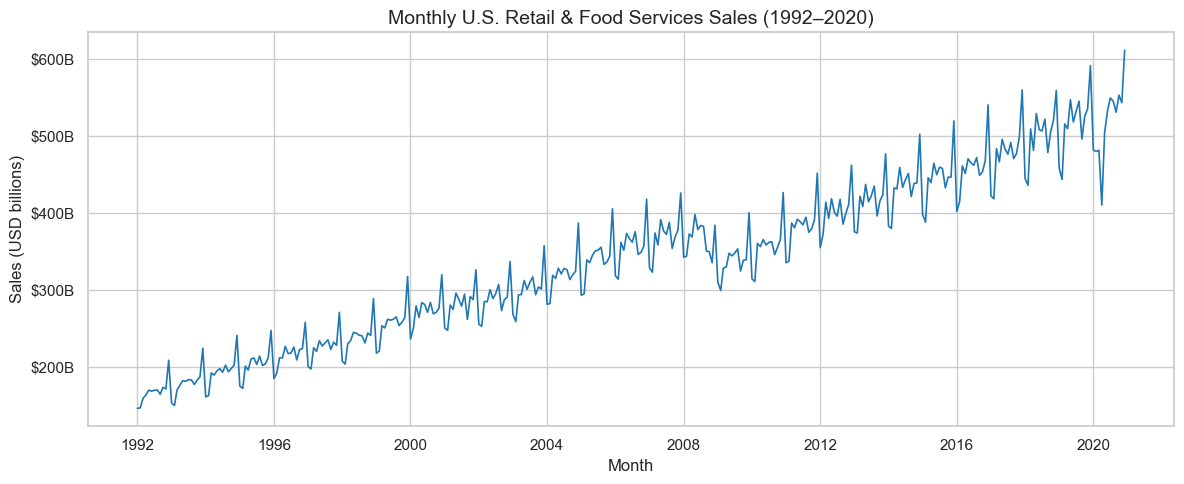

In [34]:
fig, ax = plt.subplots()
ax.plot(monthly_total['sales_month'], monthly_total['sales'] / 1_000, linewidth=1.2)
ax.set_title('Monthly U.S. Retail & Food Services Sales (1992–2020)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Sales (USD billions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}B'))
plt.tight_layout()
plt.show()

### 5.3 Yearly Aggregation — Total Retail & Food Services

In [35]:
yearly_total = sql("""
SELECT
    DATE_PART('year', sales_month) AS sales_year,
    SUM(sales)                     AS annual_sales
FROM retail_sales
WHERE kind_of_business = 'Retail and food services sales, total'
GROUP BY 1
ORDER BY 1;
""")
print(yearly_total)

    sales_year  annual_sales
0     1,992.00  2,014,102.00
1     1,993.00  2,153,095.00
2     1,994.00  2,330,235.00
3     1,995.00  2,450,628.00
4     1,996.00  2,603,794.00
5     1,997.00  2,726,131.00
6     1,998.00  2,852,956.00
7     1,999.00  3,086,990.00
8     2,000.00  3,287,537.00
9     2,001.00  3,378,906.00
10    2,002.00  3,459,077.00
11    2,003.00  3,612,457.00
12    2,004.00  3,846,605.00
13    2,005.00  4,085,746.00
14    2,006.00  4,294,359.00
15    2,007.00  4,439,733.00
16    2,008.00  4,391,580.00
17    2,009.00  4,064,476.00
18    2,010.00  4,284,968.00
19    2,011.00  4,598,302.00
20    2,012.00  4,826,390.00
21    2,013.00  5,001,763.00
22    2,014.00  5,215,656.00
23    2,015.00  5,349,487.00
24    2,016.00  5,510,186.00
25    2,017.00  5,744,810.00
26    2,018.00  6,001,623.00
27    2,019.00  6,218,002.00
28    2,020.00  6,224,399.00


### 5.4 Yearly Comparison — Book, Sporting Goods & Hobby Stores

In [36]:
category_compare = sql("""
SELECT
    DATE_PART('year', sales_month) AS sales_year,
    kind_of_business,
    SUM(sales)                     AS annual_sales
FROM retail_sales
WHERE kind_of_business IN (
    'Book stores',
    'Sporting goods stores',
    'Hobby, toy, and game stores'
)
GROUP BY 1, 2
ORDER BY 1, 2;
""")
category_compare.head(9)

,sales_year,kind_of_business,annual_sales
0,"1,992.00",Book stores,"8,327.00"
1,"1,992.00","Hobby, toy, and game stores","11,251.00"
2,"1,992.00",Sporting goods stores,"15,583.00"
3,"1,993.00",Book stores,"9,108.00"
4,"1,993.00","Hobby, toy, and game stores","11,651.00"
5,"1,993.00",Sporting goods stores,"16,791.00"
6,"1,994.00",Book stores,"10,107.00"
7,"1,994.00","Hobby, toy, and game stores","12,850.00"
8,"1,994.00",Sporting goods stores,"18,825.00"


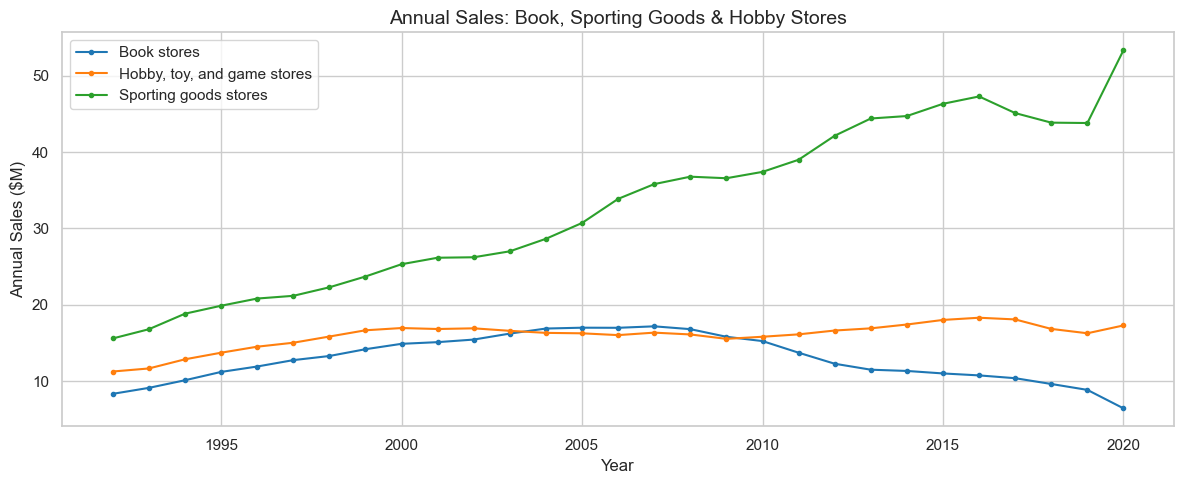

In [37]:
fig, ax = plt.subplots()
for biz, grp in category_compare.groupby('kind_of_business'):
    ax.plot(grp['sales_year'], grp['annual_sales'] / 1_000, marker='o', markersize=3, label=biz)
ax.set_title('Annual Sales: Book, Sporting Goods & Hobby Stores', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Annual Sales ($M)')
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Monthly Trend — Men's vs Women's Clothing Stores

In [38]:
clothing_monthly = sql("""
SELECT
    sales_month,
    kind_of_business,
    sales
FROM retail_sales
WHERE kind_of_business IN ('Men''s clothing stores', 'Women''s clothing stores')
ORDER BY sales_month, kind_of_business;
""")
clothing_monthly.head()

,sales_month,kind_of_business,sales
0,1992-01-01,Men's clothing stores,701.00
1,1992-01-01,Women's clothing stores,"1,873.00"
2,1992-02-01,Men's clothing stores,658.00
3,1992-02-01,Women's clothing stores,"1,991.00"
4,1992-03-01,Men's clothing stores,731.00


### 5.6 Sales Banding with `CASE`

Classifying each row as `high_sales`, `mid_sales`, or `low_sales` based on monthly figures.

In [39]:
banding = sql("""
SELECT
    sales_month,
    kind_of_business,
    sales,
    CASE
        WHEN sales >= 1000 THEN 'high_sales'
        WHEN sales <= 500  THEN 'low_sales'
        ELSE                    'mid_sales'
    END AS sales_band
FROM retail_sales
WHERE kind_of_business IN ('Men''s clothing stores', 'Women''s clothing stores')
ORDER BY sales_month, kind_of_business;
""")

print('Band distribution:')
print(banding.groupby(['kind_of_business','sales_band']).size().unstack(fill_value=0))
banding.head()

Band distribution:
sales_band               high_sales  low_sales  mid_sales
kind_of_business                                         
Men's clothing stores            22         13        313
Women's clothing stores         347          1          0


,sales_month,kind_of_business,sales,sales_band
0,1992-01-01,Men's clothing stores,701.00,mid_sales
1,1992-01-01,Women's clothing stores,"1,873.00",high_sales
2,1992-02-01,Men's clothing stores,658.00,mid_sales
3,1992-02-01,Women's clothing stores,"1,991.00",high_sales
4,1992-03-01,Men's clothing stores,731.00,mid_sales


### 5.7 Yearly Pivot — Women's vs Men's Clothing

Using conditional aggregation (`SUM(CASE WHEN ...)`) to produce a pivot-style layout.

In [40]:
pivot = sql("""
SELECT
    DATE_PART('year', sales_month)                                            AS sales_year,
    SUM(CASE WHEN kind_of_business = 'Women''s clothing stores' THEN sales END) AS women_sales,
    SUM(CASE WHEN kind_of_business = 'Men''s clothing stores'   THEN sales END) AS men_sales
FROM retail_sales
WHERE kind_of_business IN ('Men''s clothing stores', 'Women''s clothing stores')
GROUP BY 1
ORDER BY 1;
""")
print(pivot)

    sales_year  women_sales  men_sales
0     1,992.00    31,815.00  10,179.00
1     1,993.00    32,350.00   9,962.00
2     1,994.00    30,585.00  10,032.00
3     1,995.00    28,696.00   9,315.00
4     1,996.00    28,238.00   9,546.00
5     1,997.00    27,822.00  10,069.00
6     1,998.00    28,332.00  10,196.00
7     1,999.00    29,549.00   9,667.00
8     2,000.00    31,447.00   9,507.00
9     2,001.00    31,453.00   8,625.00
10    2,002.00    31,246.00   8,112.00
11    2,003.00    32,565.00   8,249.00
12    2,004.00    34,954.00   8,566.00
13    2,005.00    37,075.00   8,737.00
14    2,006.00    38,809.00   8,844.00
15    2,007.00    40,294.00   8,772.00
16    2,008.00    38,402.00   8,351.00
17    2,009.00    36,055.00   7,353.00
18    2,010.00    37,690.00   7,285.00
19    2,011.00    40,048.00   7,860.00
20    2,012.00    41,794.00   8,272.00
21    2,013.00    41,787.00   8,670.00
22    2,014.00    41,575.00   8,870.00
23    2,015.00    41,065.00   8,810.00
24    2,016.00    40,845.

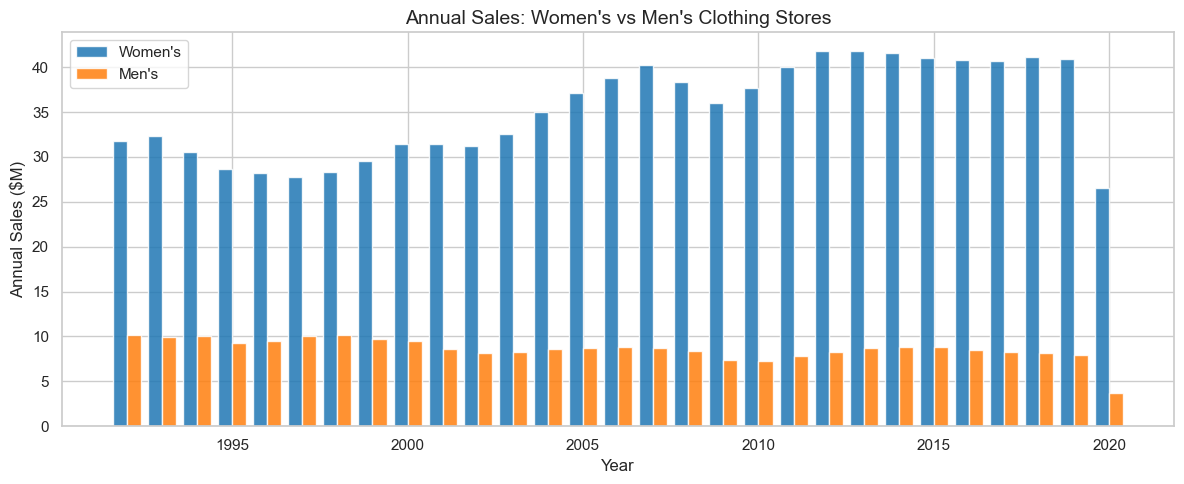

In [41]:
fig, ax = plt.subplots()
ax.bar(pivot['sales_year'] - 0.2, pivot['women_sales'] / 1_000, width=0.4, label="Women's", alpha=0.85)
ax.bar(pivot['sales_year'] + 0.2, pivot['men_sales']   / 1_000, width=0.4, label="Men's",   alpha=0.85)
ax.set_title("Annual Sales: Women's vs Men's Clothing Stores", fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Annual Sales ($M)')
ax.legend()
plt.tight_layout()
plt.show()

### 5.8 Absolute Difference — Women's minus Men's (up to 2019)

In [42]:
sql("""
SELECT
    DATE_PART('year', sales_month)                                               AS sales_year,
    SUM(CASE WHEN kind_of_business = 'Women''s clothing stores' THEN sales END)
  - SUM(CASE WHEN kind_of_business = 'Men''s clothing stores'   THEN sales END) AS womens_minus_mens
FROM retail_sales
WHERE kind_of_business IN ('Men''s clothing stores', 'Women''s clothing stores')
  AND sales_month <= DATE '2019-12-01'
GROUP BY 1
ORDER BY 1;
""")

,sales_year,womens_minus_mens
0,"1,992.00","21,636.00"
1,"1,993.00","22,388.00"
2,"1,994.00","20,553.00"
3,"1,995.00","19,381.00"
4,"1,996.00","18,692.00"
5,"1,997.00","17,753.00"
6,"1,998.00","18,136.00"
7,"1,999.00","19,882.00"
8,"2,000.00","21,940.00"
9,"2,001.00","22,828.00"


### 5.9 Percent Difference — Women's vs Men's (up to 2019)

Formula: `((women / men) - 1) × 100`  
A positive value means Women's outsells Men's by that percentage.

In [43]:
pct_diff = sql("""
WITH yearly AS (
    SELECT
        DATE_PART('year', sales_month)                                               AS sales_year,
        SUM(CASE WHEN kind_of_business = 'Women''s clothing stores' THEN sales END) AS womens_sales,
        SUM(CASE WHEN kind_of_business = 'Men''s clothing stores'   THEN sales END) AS mens_sales
    FROM retail_sales
    WHERE kind_of_business IN ('Men''s clothing stores', 'Women''s clothing stores')
      AND sales_month <= DATE '2019-12-01'
    GROUP BY 1
)
SELECT
    sales_year,
    womens_sales,
    mens_sales,
    ROUND(((womens_sales::NUMERIC / mens_sales::NUMERIC) - 1) * 100.0, 2) AS womens_pct_of_mens
FROM yearly
ORDER BY sales_year;
""")
print(pct_diff.to_string(index=False))

 sales_year  womens_sales  mens_sales  womens_pct_of_mens
   1,992.00     31,815.00   10,179.00              212.56
   1,993.00     32,350.00    9,962.00              224.73
   1,994.00     30,585.00   10,032.00              204.87
   1,995.00     28,696.00    9,315.00              208.06
   1,996.00     28,238.00    9,546.00              195.81
   1,997.00     27,822.00   10,069.00              176.31
   1,998.00     28,332.00   10,196.00              177.87
   1,999.00     29,549.00    9,667.00              205.67
   2,000.00     31,447.00    9,507.00              230.78
   2,001.00     31,453.00    8,625.00              264.67
   2,002.00     31,246.00    8,112.00              285.18
   2,003.00     32,565.00    8,249.00              294.78
   2,004.00     34,954.00    8,566.00              308.06
   2,005.00     37,075.00    8,737.00              324.34
   2,006.00     38,809.00    8,844.00              338.82
   2,007.00     40,294.00    8,772.00              359.35
   2,008.00   

### 5.10 Percent of Monthly Total — Two Approaches

Both approaches compute each category's share of the combined Men's + Women's monthly total.

**Approach A:** CTE + self-join  
**Approach B:** Window function — cleaner, no self-join

In [44]:
# Approach A: CTE + JOIN
pct_join = sql("""
WITH base AS (
    SELECT sales_month, kind_of_business, sales
    FROM retail_sales
    WHERE kind_of_business IN ('Men''s clothing stores', 'Women''s clothing stores')
),
totals AS (
    SELECT sales_month, SUM(sales) AS total_sales
    FROM base
    GROUP BY sales_month
)
SELECT
    b.sales_month,
    b.kind_of_business,
    b.sales,
    ROUND((b.sales::NUMERIC * 100.0) / t.total_sales::NUMERIC, 2) AS pct_of_monthly_total
FROM base b
JOIN totals t ON b.sales_month = t.sales_month
ORDER BY b.sales_month, b.kind_of_business;
""")
print('Approach A (JOIN):')
pct_join.head(6)

Approach A (JOIN):


,sales_month,kind_of_business,sales,pct_of_monthly_total
0,1992-01-01,Men's clothing stores,701.00,27.23
1,1992-01-01,Women's clothing stores,"1,873.00",72.77
2,1992-02-01,Men's clothing stores,658.00,24.84
3,1992-02-01,Women's clothing stores,"1,991.00",75.16
4,1992-03-01,Men's clothing stores,731.00,23.32
5,1992-03-01,Women's clothing stores,"2,403.00",76.68


In [45]:
# Approach B: Window Function (preferred)
pct_window = sql("""
SELECT
    sales_month,
    kind_of_business,
    sales,
    SUM(sales) OVER (PARTITION BY sales_month)                                    AS monthly_total,
    ROUND(
        (sales::NUMERIC * 100.0) / SUM(sales) OVER (PARTITION BY sales_month)
    , 2)                                                                          AS pct_of_monthly_total
FROM retail_sales
WHERE kind_of_business IN ('Men''s clothing stores', 'Women''s clothing stores')
ORDER BY sales_month, kind_of_business;
""")
print('Approach B (Window Function):')
pct_window.head(6)

ProgrammingError: (psycopg2.errors.UndefinedFunction) function round(double precision, integer) does not exist
LINE 7:     ROUND(
            ^
HINT:  No function matches the given name and argument types. You might need to add explicit type casts.

[SQL: 
SELECT
    sales_month,
    kind_of_business,
    sales,
    SUM(sales) OVER (PARTITION BY sales_month)                                    AS monthly_total,
    ROUND(
        (sales::NUMERIC * 100.0) / SUM(sales) OVER (PARTITION BY sales_month)
    , 2)                                                                          AS pct_of_monthly_total
FROM retail_sales
WHERE kind_of_business IN ('Men''s clothing stores', 'Women''s clothing stores')
ORDER BY sales_month, kind_of_business;
]
(Background on this error at: https://sqlalche.me/e/20/f405)

### 5.11 Yearly Share — Each Month as % of Annual Total

For each row, what fraction of that category's **annual** sales did this month contribute?

In [46]:
sql("""
SELECT
    sales_month,
    kind_of_business,
    sales,
    SUM(sales) OVER (
        PARTITION BY DATE_PART('year', sales_month), kind_of_business
    )                                                                             AS yearly_total,
    ROUND(
        (sales::NUMERIC * 100.0)
        / SUM(sales) OVER (PARTITION BY DATE_PART('year', sales_month), kind_of_business)
    , 2)                                                                          AS pct_of_annual
FROM retail_sales
WHERE kind_of_business IN ('Men''s clothing stores', 'Women''s clothing stores')
ORDER BY DATE_PART('year', sales_month), kind_of_business, sales_month
LIMIT 24;
""")

ProgrammingError: (psycopg2.errors.UndefinedFunction) function round(double precision, integer) does not exist
LINE 9:     ROUND(
            ^
HINT:  No function matches the given name and argument types. You might need to add explicit type casts.

[SQL: 
SELECT
    sales_month,
    kind_of_business,
    sales,
    SUM(sales) OVER (
        PARTITION BY DATE_PART('year', sales_month), kind_of_business
    )                                                                             AS yearly_total,
    ROUND(
        (sales::NUMERIC * 100.0)
        / SUM(sales) OVER (PARTITION BY DATE_PART('year', sales_month), kind_of_business)
    , 2)                                                                          AS pct_of_annual
FROM retail_sales
WHERE kind_of_business IN ('Men''s clothing stores', 'Women''s clothing stores')
ORDER BY DATE_PART('year', sales_month), kind_of_business, sales_month
LIMIT 24;
]
(Background on this error at: https://sqlalche.me/e/20/f405)

### 5.12 Index Analysis — Growth vs Base Year

Using `FIRST_VALUE()` to pin the earliest year as the index (= 100 %) and compute each subsequent year's percentage change.

**Formula:** `(year_sales / first_year_sales − 1) × 100`

In [47]:
# Step 1: view the base-year anchor via FIRST_VALUE
sql("""
SELECT
    sales_year,
    sales,
    FIRST_VALUE(sales) OVER (ORDER BY sales_year) AS index_sales
FROM (
    SELECT
        DATE_PART('year', sales_month) AS sales_year,
        SUM(sales)                     AS sales
    FROM retail_sales
    WHERE kind_of_business = 'Women''s clothing stores'
    GROUP BY 1
) a
ORDER BY sales_year;
""")

,sales_year,sales,index_sales
0,"1,992.00","31,815.00","31,815.00"
1,"1,993.00","32,350.00","31,815.00"
2,"1,994.00","30,585.00","31,815.00"
3,"1,995.00","28,696.00","31,815.00"
4,"1,996.00","28,238.00","31,815.00"
5,"1,997.00","27,822.00","31,815.00"
6,"1,998.00","28,332.00","31,815.00"
7,"1,999.00","29,549.00","31,815.00"
8,"2,000.00","31,447.00","31,815.00"
9,"2,001.00","31,453.00","31,815.00"


In [ ]:
# Step 2: compute % change from the base year
index_growth = sql("""
WITH yearly AS (
    SELECT
        DATE_PART('year', sales_month) AS sales_year,
        SUM(sales)                     AS sales
    FROM retail_sales
    WHERE kind_of_business = 'Women''s clothing stores'
    GROUP BY 1
)
SELECT
    sales_year,
    sales,
    FIRST_VALUE(sales) OVER (ORDER BY sales_year)                 AS index_sales,
    ROUND(
        (sales / FIRST_VALUE(sales) OVER (ORDER BY sales_year) - 1) * 100
    , 2)                                                          AS pct_from_index
FROM yearly
ORDER BY sales_year;
""")
print(index_growth.to_string(index=False))

In [ ]:
fig, ax = plt.subplots()
ax.bar(
    index_growth['sales_year'],
    index_growth['pct_from_index'],
    color=['#d62728' if v < 0 else '#2ca02c' for v in index_growth['pct_from_index']]
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title("Women's Clothing Stores — % Growth vs 1992 Base Year", fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('% Change from 1992')
plt.tight_layout()
plt.show()

### 5.13 Rolling Time Windows

Rolling averages smooth out seasonal noise and reveal the underlying trend.  
Using a **12-month trailing window** on Women's clothing monthly sales.

In [ ]:
rolling = sql("""
SELECT
    sales_month,
    sales                                           AS monthly_sales,
    ROUND(
        AVG(sales) OVER (
            ORDER BY sales_month
            ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
        )
    , 2)                                            AS rolling_12m_avg,
    ROUND(
        SUM(sales) OVER (
            ORDER BY sales_month
            ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
        )
    , 2)                                            AS rolling_12m_sum
FROM retail_sales
WHERE kind_of_business = 'Women''s clothing stores'
ORDER BY sales_month;
""")
rolling.tail(12)

In [ ]:
fig, ax = plt.subplots()
ax.plot(rolling['sales_month'], rolling['monthly_sales'],    alpha=0.4, linewidth=1,   label='Monthly')
ax.plot(rolling['sales_month'], rolling['rolling_12m_avg'], linewidth=2, color='#d62728', label='12-Month Rolling Avg')
ax.set_title("Women's Clothing Stores — Monthly Sales vs 12-Month Rolling Average", fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($M)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Key Findings

| Insight | Detail |
|---------|--------|
| **Long-run growth** | Total retail & food services roughly doubled from ~\$150B/yr (1992) to ~\$6T/yr (2020) |
| **Seasonality** | Strong December spikes visible across virtually all categories — holiday effect |
| **Category divergence** | Book stores peaked in the mid-2000s then collapsed (Amazon effect); Sporting Goods & Hobby stores held steady |
| **Gender gap in clothing** | Women's clothing consistently outsells Men's by **~200–250%** throughout the dataset |
| **COVID impact (2020)** | Women's clothing saw a sharp YoY decline in 2020, visible in both raw figures and the index chart |
| **Rolling average** | The 12-month rolling average smooths seasonal spikes and reveals a steady growth trend with a 2020 dip |

---

## References

- U.S. Census Bureau — [Monthly Retail Trade Survey](https://www.census.gov/retail/index.html)  
- PostgreSQL Documentation — [Date/Time Functions](https://www.postgresql.org/docs/current/functions-datetime.html)  
- Cathy Tanumura — *SQL for Data Analysis* (O'Reilly)

---
*Teslim Adeyanju, ACA — [github.com/Teslim-Adeyanju](https://github.com/Teslim-Adeyanju)*